# Introducting The Kernel Trick

### 1. Explicit Transformations

In soft-margin SVC, we assume that our data is roughly linearly seperable in feature space. However, this is often not the case in reality. In these situations, we may try the kernel trick which involves transforming our data into a new feature space. Within this new feature space, our transformed data may be perfectly or roughly linearly seperable. Moreover, the kernel trick allows to consider the transformed feature space without explicitly performing the transformation on the original dataset. As a result, computational costs are reduced since directly transformation our data usually an expensive process. Let us consider the following data,

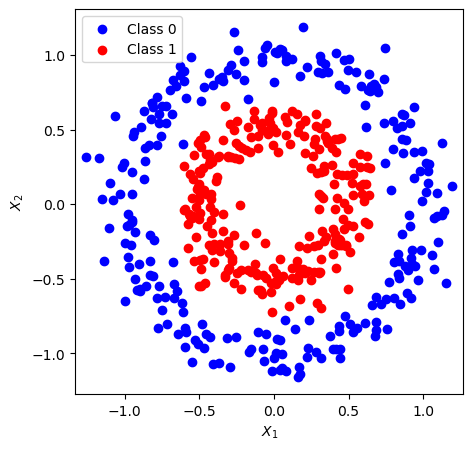

In [1]:
# Importing,
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# Creating datasets,
X, y = make_circles(n_samples=500, noise=0.10, factor=0.5, random_state=0)

# Ploting data,
plt.figure(figsize=(5,5))
plt.scatter(X[y==0, 0], X[y==0, 1], color="blue", label="Class 0")
plt.scatter(X[y==1, 0], X[y==1, 1], color="red", label="Class 1")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.legend()
plt.axis("equal")
plt.show()

Our data consists of $M=2$ classes labelled as $0$ and $1$. The data point of each respective class [...]. This is a typical example used to demonstate how data which is not separable in the original feature space can be transformed into another feature space where it is. Let us consider transforming our data by adding an additional feature $X_{i3}$. We use our existing data to create this new feature such that $X_{i3} = X_{i1}^2 + X_{i2}^2$. Therefore, we say that we have performed the explicit transformation $\hat{T}$ on $X_i$ such that $\hat{T}(X_i) = X_i^{'}$ where $X_i^{'} = [X_{i1}, X_{i2}, X_{i3}]$. We are easily able to see that the transformed data exists in a feature space where it is pefectly linearly seperable by a plane as the decision boundary,

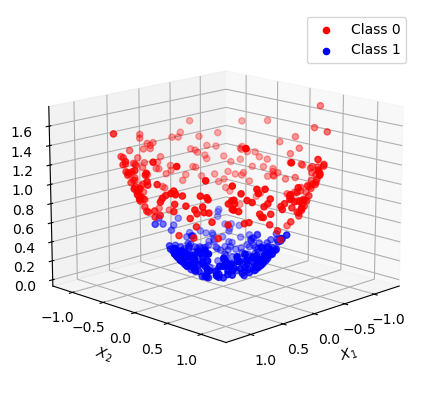

In [2]:
# Creating the additional feature,
X1, X2 = X.T[0], X.T[1]
X3 = X1**2 + X2**2
X_trans = np.concatenate((X, X3.reshape(-1, 1)), axis=1)

# Plotting,
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(projection="3d")
ax.scatter(X_trans[y==0, 0], X_trans[y==0, 1], X_trans[y==0, 2], color="red", label="Class 0")
ax.scatter(X_trans[y==1, 0], X_trans[y==1, 1], X_trans[y==1, 2], color="blue", label="Class 1")
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.set_zlabel("$X_3$") 
ax.view_init(elev=15, azim=45)
plt.legend()
plt.show()

This allows us to train a linear SVC model on the transformed dataset, 

In [3]:
# Imports,
from models.BaseSVM import BaseSVC
from sklearn.model_selection import train_test_split

# Creating data split,
X_train, X_test, y_train, y_test = train_test_split(X_trans, y, test_size=0.2, random_state=0)

# Training model,
clf = BaseSVC()
clf.fit(X_train, y_train)
clf.score(X_test, y_test)
clf

From the parameters of our model, $W_i$ and $b$, we can construct the decision boundary in both the original and transformed feature space,

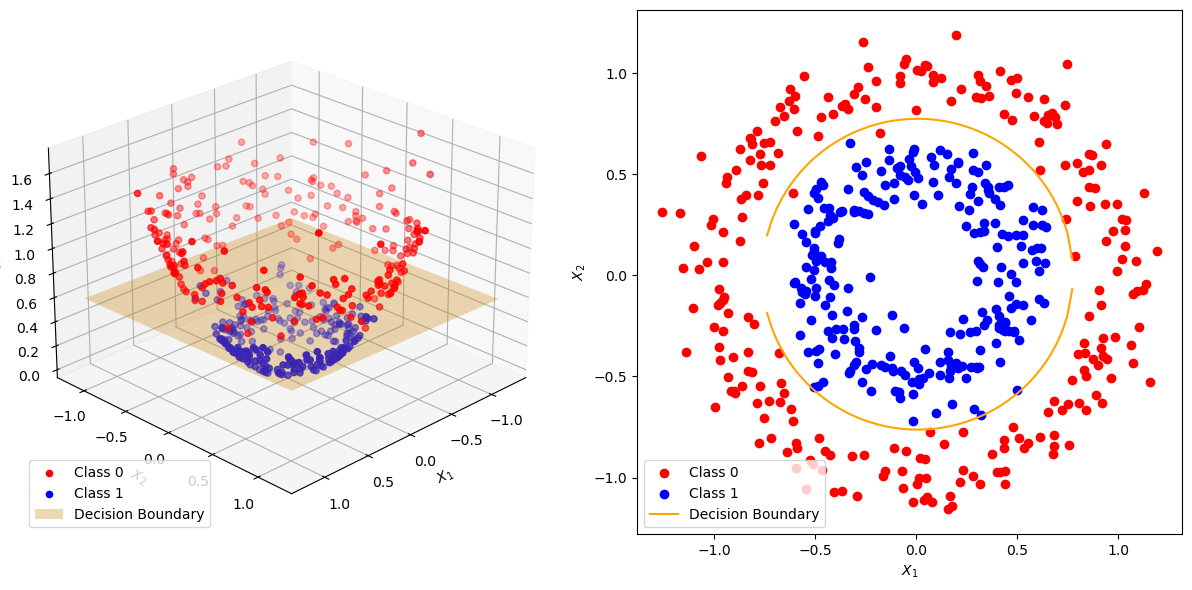

In [5]:
# Extracting model parameters,
W1, W2, W3 = clf.weights[0], clf.weights[1], clf.weights[2]
b = clf.bias

# Constructing decision boundary,
X1_range = np.linspace(X1.min(), X1.max(), 30)
X2_range = np.linspace(X2.min(), X2.max(), 30)
X1_grid, X2_grid = np.meshgrid(X1_range, X2_range)
X3_grid = -1*(W1*X1_grid + W2*X2_grid + b)/W3

# Constructing decision boundary in 2D,
X1_range = np.linspace(X1.min(), X1.max(), 100)
discriminant = W2**2 - 4*W3*(W3*X1_range**2 + W1*X1_range + b) # <-- Computing discriminant.
mask = discriminant >= 0 # <-- Applying mask and reconstructing decision boundary.
X1_range, discriminant  = X1_range[mask], discriminant[mask]
X2_range_pos = (-W2 + np.sqrt(discriminant)) / (2*W3)
X2_range_neg = (-W2 - np.sqrt(discriminant)) / (2*W3)

"""PLOTTING"""

# Creating figure,
fig = plt.figure(figsize=(12, 6))

# Creating 3D plot,
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(X_trans[y==0, 0], X_trans[y==0, 1], X_trans[y==0, 2], color="red", label="Class 0")
ax1.scatter(X_trans[y==1, 0], X_trans[y==1, 1], X_trans[y==1, 2], color="blue", label="Class 1")
ax1.plot_surface(X1_grid, X2_grid, X3_grid, color="orange", alpha=0.3, label="Decision Boundary")  # <-- Decision boundary.
ax1.set_xlabel("$X_1$")
ax1.set_ylabel("$X_2$")
ax1.set_zlabel("$X_3$")
ax1.view_init(elev=25, azim=45)
ax1.legend(loc="lower left")

# Creating 2D plot,
ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(X[:,0][y==0], X[:,1][y==0], color="red", label="Class 0")
ax2.scatter(X[:,0][y==1], X[:,1][y==1], color="blue", label="Class 1")
ax2.plot(X1_range, X2_range_neg, color="orange", label="Decision Boundary")
ax2.plot(X1_range, X2_range_pos, color="orange")
ax2.set_xlabel("$X_1$")
ax2.set_ylabel("$X_2$")
ax2.legend(loc="lower left")
ax2.axis('equal')

# Displaying plot,
plt.tight_layout()
plt.show()

We see that the decision boundary in the transformed space is a plane with the equation of the form,

$$
W_1 X_{i1} + W_2 X_{i2} + W_3 X_{i3} + b = 0
$$

One is able to reconstruct the non-linear decision boundary in the original space by considering $X_{i3} = X_{i1}^2 + X_{i2}^2$,

[Equation]

From the form of the equation, we know that the decision boundary transformed back into the original space is a circle.

### 2. Introducing Kernels

While explicitly transforming data into another feature space is a useful tool to create linearly separable data, it becomes computationally expensive when dealing with many features in combination with larger datasets. Recall that the dual formulation of a soft-margin SVC is, 

$$
\begin{aligned}
& \max_{\alpha_i} \quad J(\alpha_i) = \sum_{i=1}^{N} \alpha_i - \frac{1}{2} \sum_{i=1}^{N} \sum_{j=1}^{N} \alpha_i \alpha_j y_i y_j X_i X_j^T \\
& \text{subject to:} \quad \sum_{i=1}^{N} \alpha_i y_i = 0, \quad 0 \leq \alpha_i \leq C, \quad 0 \leq \beta_i \leq C \quad \forall \ i = 1, \dots, N\\
& \text{such that:} \quad \alpha_i \left[ y_i (X_iW^T + b) + \xi_i -1 \right] = 0 \quad \text{and} \quad \beta_i \epsilon_i = 0
\end{aligned}
$$

In this optimisation problem, we attempt to solve for the multipliers $\alpha_i$ that maximise our dual function $J(\alpha_i)$ and which are required to calculate the model parameters. Notably, the problem is formulated with the dot-products of the data, $X_i X_j^T$, rather than the individual data points $X_i$ themselves. This means that when we perform an explict transformation on the data, the dot products become $\phi(X_i) \phi(X_j)^T$. As mentioned previously, performing this explicit transformation may be computationally expensive. Therefore, the transformed dot products are replaced with the kernel function such that $K(X_i, X_j) = \phi(X_i) \phi(X_j)^T$. With a kernel function, the optimisation problem is,  

$$
\begin{aligned}
& \max_{\alpha_i} \quad J(\alpha_i) = \sum_{i=1}^{N} \alpha_i - \frac{1}{2} \sum_{i=1}^{N} \sum_{j=1}^{N} \alpha_i \alpha_j y_i y_j K(X_i, X_j) \\
& \text{subject to:} \quad \sum_{i=1}^{N} \alpha_i y_i = 0, \quad 0 \leq \alpha_i \leq C, \quad 0 \leq \beta_i \leq C \quad \forall \ i = 1, \dots, N\\
& \text{such that:} \quad \alpha_i \left[ y_i (X_iW^T + b) + \xi_i -1 \right] = 0 \quad \text{and} \quad \beta_i \epsilon_i = 0
\end{aligned}
$$

where it is important to note that, 

$$
X_iW^T = \sum_{k=1}^N \alpha_k y_k K(X_i, X_j)
$$

In previous notebooks, we showed that it is more convenient to write the optimisation problem as the following for implementation,

$$
\begin{aligned}
& \min_{\boldsymbol{\alpha}} \quad J(\boldsymbol{\alpha}) = \frac{1}{2} \boldsymbol{\alpha}^T (Q\boldsymbol{\alpha}) - \mathbf{1}^T\boldsymbol{\alpha} \\
& \text{subject to:} \quad \mathbf{y}^T \boldsymbol{\alpha} = 0, \quad 0 \leq \alpha_i \leq C, \quad 0 \leq \beta_i \leq C \quad \forall \ i = 1, \dots, N
\end{aligned}
$$

The elements of the Q-matrix $Q$ with kernelisation is given by, 

$$
Q_{ij} = y_i y_j K(X_i, X_j)
$$

something

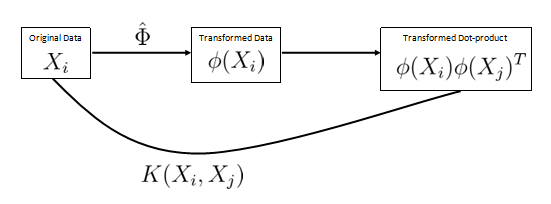


### Basic Implementation

In [1]:
# Dependencies,
import numpy as np
from cvxopt import matrix, solvers

class KernelBaseSVC:
    """Class for the support vector classifier (SVC)."""

    def __init__(self, C=1, kernel="linear", kernel_params=None):
        """Constructor method."""

        # Model parameters,
        self.weights, self.bias = None, None
        self.label = "support vector classifier (soft-margin)"
        self.kernel, self.kernel_params = kernel, kernel_params
        self.fitted, self.scored = False, False
        self.C = C

        # Training data,
        self.X, self.y = None, None
        self.n_samples, self.n_features = None, None
        self.model_score = None

        # Related to the optimisation algorithm,
        self.Q_matrix = None
        self.alphas = None
        self.sv_idxs = None
        self.n_sv = None

    def fit(self, X, y):
        """Use this method to fit the model."""

        # Assigning data properties,
        self.X, self.y = X, np.where(y <= 0, -1, 1) # <-- Re-labeling class labels.
        self.n_samples, self.n_features = X.shape[0], X.shape[1]

        # Computing our Lagrangian multipliers,
        self.alphas = self._solve_dual_()

        # Computing model parameters,
        self.bias = np.mean([self.y[i] - self._decision_function(self.X[i], bias=False) for i in self.sv_idxs])

        # Update fitted state,
        self.fitted = True

    def predict(self, X):
        """This method returns the predictions when supplied with samples."""
        return np.array([np.sign(self._decision_function(X_i)).astype(int) for X_i in X])

    def score(self, X, y):
        """Computes the classification accuracy on the provided data."""

        # Re-labeling class labels,
        y = np.where(y <= 0, -1, 1)
        
        # Computing predictions,
        y_pred = self.predict(X)

        # Calculating classification accuracy,
        accuracy = np.mean(y_pred == y)
        self.model_score = accuracy
        self.scored = True

        return accuracy

    def _solve_dual_(self, verbose=False, epsilon=1e-5):
        """Finds the Lagrange multipliers which maximise the dual function for the hard-margin SVC."""

        # Constructing the Q matrix (weighted Gram matrix),
        self.Q_matrix = np.outer(self.y, self.y)*self._kernel_matrix(self.X)
        ones_vector = np.ones(self.n_samples, dtype=np.double)

        """Translating into CVXOPT formalism."""

        # Objective function,
        P_matrix_obj = matrix(self.Q_matrix.astype(np.double)) # <-- Wrapping the matrix  
        q_vector_obj = matrix(-1*ones_vector)

        # Constraint (1),
        G_std = -np.eye(self.n_samples)
        h_std = np.zeros(self.n_samples)

        G_slack = np.eye(self.n_samples)
        h_slack = np.ones(self.n_samples) * self.C

        G_object = matrix(np.vstack((G_std, G_slack)))
        h_object = matrix(np.hstack((h_std, h_slack)))

        # Constraint (2),
        A_object = matrix(self.y.reshape(1, -1).astype(np.double))
        b_object = matrix([0.0])

        # Solving,
        if not verbose:
            solvers.options['show_progress'] = False
        sol = solvers.qp(P=P_matrix_obj , q=q_vector_obj, G=G_object, h=h_object, A=A_object, b=b_object)
        alphas = np.asarray(sol["x"]).flatten() # <-- Extracting Lagrange multipliers.

        # Extracting support vectors,
        self.sv_idxs = np.where(alphas > epsilon)[0]
        self.n_sv = len(self.sv_idxs)

        return alphas

    def _decision_function(self, X, bias=True):
        """Returns the distance a sample is from the decision boundary in feature space."""
        self.kernel_vector = np.array([self._kernel_function(X, X_j) for X_j in self.X])
        return np.sum(self.alphas*self.y*self.kernel_vector) + self.bias if bias else np.sum(self.alphas*self.y*self.kernel_vector)
    
    def _compute_slack(self, epsilon_bound=1e-3):
        """Computes the slack variable for each training sample and its assoiated Lagrange multiplier. Returns a tuple."""

        # Computing the lagrange multipliers,
        slack_multipliers = self.C - self.alphas

        # Computing slack variables,
        slack_vars = np.zeros(shape=self.n_samples)
        mask = (self.alphas > self.C - epsilon_bound) & (self.alphas < self.C + epsilon_bound) # <-- We create a mask.
        selected_idxs = mask.nonzero()[0] # <-- Extracting indices where condition was met.
        for idx in selected_idxs:
            slack_vars[idx] = 1 - self.y[idx]*(np.dot(self.X[idx], self.weights) + self.bias)
        
        return slack_vars, slack_multipliers

    def _kernel_matrix(self, X):
        """Generates the kernel matrix of the data which is used to construct the Q-matrix."""

        if self.kernel == "linear":
            return np.dot(X, self.X.T)

        if self.kernel == "custom":
            K = np.dot(X, X.T) # <-- Linear kernel matrix.
            return K + np.diag(K)[:, None] * np.diag(K)[None, :]

    def _kernel_function(self, X_i, X_j):
        """The kernel function of the SVC."""

        if self.kernel == "linear":
            return np.dot(X_i, X_j)

        if self.kernel == "custom":
            return np.dot(X_i, X_j) + (np.dot(X_i, X_i) * np.dot(X_j, X_j))
    
    def _repr_html_(self):
        """Compact HTML GUI as the object representation in Jupyter Notebook."""
        html = f"""
        <div style="
            border:1px solid black;
            border-radius:6px;
            font-family:Arial, sans-serif;
            font-size:12px;
            line-height:1.2;
            width:fit-content;
            background:white;
            color:black;
            padding-left:8px;
            padding-right:8px;
        ">
            <!-- Title bar -->
            <i>{self.label}</i>
            <div style="
                background:#e0e0e0;
                padding:3px 6px;
                font-weight:bold;
                border-bottom:1px solid black;
                border-top-left-radius:6px;
                border-top-right-radius:6px;
                color:black;
            ">
                SVC
                <div style="margin-top:2px;">
                    <img src="svc_icon.png" alt="tree icon" width="30" height="30">
                </div>
            </div>

            <!-- Hyperparameters -->
            <ul style="margin:4px 0 4px 16px; padding:0;">
                <b>Hyperparameters:</b><br>
                self.C:</b> {self.C}<br>
                self.kernel:</b> {self.kernel}<br>
                self.kernel_params:</b> {self.kernel_params}<br>
            </ul>

            <!-- Divider -->
            <div style="
                border-top:1px solid #ccc;
                margin:4px 0;
            "></div>

            <!-- Status and other info -->
            <ul style="margin:4px 0 4px 16px; padding:0;">
        """

        if self.fitted:
            html += "<b>Status:</b> <span style='color:green;'>Fitted</span><br>"
            html += f"Score:</b>{round(self.model_score, 3) if self.scored == True else None}<br>"
            html += f"self.n_features:</b> {self.n_features}<br>"
            html += f"self.n_samples:</b> {self.n_samples}<br>"
            html += f"self.n_sv:</b> {self.n_sv}<br>"
        else:
            html += "<b>Status:</b> <span style='color:red;'>Not Fitted</span><br>"

        return html

In [9]:
# Creating data split,
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Training model,
clf = KernelBaseSVC(kernel="linear")
clf.fit(X_train, y_train)
clf.score(X_test, y_test)
clf

In [10]:
# Creating data split,
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Training model,
clf = KernelBaseSVC(kernel="custom")
clf.fit(X_train, y_train)
clf.score(X_test, y_test)
clf

### References

https://www.youtube.com/watch?v=OKFMZQyDROI